In [ ]:
import mysql.connector
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# Phase 8.1 & 8.2: Data Extraction & Cleaning
# ---------------------------------------------------------

try:
    connection = mysql.connector.connect(
        host="localhost",
        user="root",
        password="anything", # IMPORTANT: Replace before running
        database="race_pacing_engine"
    )
    
    # We are pulling the raw split data for David (Consistent) and Yuki (Negative Split) to analyze pacing
    query = """
    SELECT 
        sl.RegID,
        r.FirstName,
        r.Gender,
        vw.AgeOnRaceDay,
        sl.Kilometer_Mark,
        sl.Chip_Timestamp
    FROM SplitLogs sl
    JOIN Registrations reg ON sl.RegID = reg.RegID
    JOIN Runners r ON reg.RunnerID = r.RunnerID
    JOIN vw_runner_demographics vw ON reg.RegID = vw.RegID
    WHERE reg.RaceID = 1 AND sl.RegID IN (5, 8)
    ORDER BY sl.RegID, sl.Kilometer_Mark;
    """

    df_splits = pd.read_sql(query, connection)
    print("✅ Data Extracted Successfully.\n")

except mysql.connector.Error as e:
    print(f"❌ Error: {e}")
finally:
    if 'connection' in locals() and connection.is_connected():
        connection.close()

# 1. Check for Missing Values (Cleaning)
print("Missing Values Check:")
print(df_splits.isnull().sum())

# 2. Fix Data Types (Cleaning/Validation)
# Ensure timestamps are actual pandas datetime objects so we can perform math on them
df_splits['Chip_Timestamp'] = pd.to_datetime(df_splits['Chip_Timestamp'])
print("\nData Types Validated:\n", df_splits.dtypes)


# ---------------------------------------------------------
# Phase 8.4: Feature Engineering (The Analytical Heavy Lifting)
# ---------------------------------------------------------
# We need to calculate how long each 5km segment took, and the pace per km.

# 1. Calculate 'Previous Mat Timestamp' using shift() (Pandas equivalent of SQL LAG())
df_splits['Previous_Timestamp'] = df_splits.groupby('RegID')['Chip_Timestamp'].shift(1)

# 2. Calculate the Duration of the Split in Minutes
df_splits['Split_Duration_Mins'] = (df_splits['Chip_Timestamp'] - df_splits['Previous_Timestamp']).dt.total_seconds() / 60

# 3. Calculate 'Previous Kilometer Mark' to find the exact distance of this split
df_splits['Previous_KM'] = df_splits.groupby('RegID')['Kilometer_Mark'].shift(1)

# Handle the first split (5km). The previous KM was 0, and the start time was 06:00:00
race_start_time = pd.to_datetime('2026-09-10 06:00:00')

df_splits['Previous_Timestamp'] = df_splits['Previous_Timestamp'].fillna(race_start_time)
df_splits['Previous_KM'] = df_splits['Previous_KM'].fillna(0.0)

# Recalculate duration for the first split now that NaNs are filled
df_splits['Split_Duration_Mins'] = (df_splits['Chip_Timestamp'] - df_splits['Previous_Timestamp']).dt.total_seconds() / 60

# 4. Calculate Distance Covered in this specific split
df_splits['Split_Distance_KM'] = df_splits['Kilometer_Mark'] - df_splits['Previous_KM']

# 5. Calculate Pace (Minutes per Kilometer)
df_splits['Pace_Min_Per_KM'] = df_splits['Split_Duration_Mins'] / df_splits['Split_Distance_KM']

# Clean up temporary columns we don't need for the final report
df_splits = df_splits.drop(columns=['Previous_Timestamp', 'Previous_KM'])

print("\n🚀 Feature Engineering Complete. Final DataFrame:")
display(df_splits)

✅ Data Extracted Successfully.

Missing Values Check:
RegID             0
FirstName         0
Gender            0
AgeOnRaceDay      0
Kilometer_Mark    0
Chip_Timestamp    0
dtype: int64

Data Types Validated:
 RegID                      int64
FirstName                 object
Gender                    object
AgeOnRaceDay               int64
Kilometer_Mark           float64
Chip_Timestamp    datetime64[ns]
dtype: object

🚀 Feature Engineering Complete. Final DataFrame:


C:\Users\Anshul Thakur\AppData\Local\Temp\ipykernel_33688\110392142.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_splits = pd.read_sql(query, connection)


,RegID,FirstName,Gender,AgeOnRaceDay,Kilometer_Mark,Chip_Timestamp,Split_Duration_Mins,Split_Distance_KM,Pace_Min_Per_KM
0,5,David,M,35,5.0,2026-09-10 06:16:15,16.250000,5.0,3.250000
1,5,David,M,35,10.0,2026-09-10 06:32:30,16.250000,5.0,3.250000
2,5,David,M,35,15.0,2026-09-10 06:48:45,16.250000,5.0,3.250000
3,5,David,M,35,20.0,2026-09-10 07:05:00,16.250000,5.0,3.250000
4,5,David,M,35,21.1,2026-09-10 07:08:34,3.566667,1.1,3.242424
5,8,Yuki,M,27,5.0,2026-09-10 06:25:00,25.000000,5.0,5.000000
6,8,Yuki,M,27,10.0,2026-09-10 06:49:30,24.500000,5.0,4.900000
7,8,Yuki,M,27,15.0,2026-09-10 07:13:00,23.500000,5.0,4.700000
8,8,Yuki,M,27,20.0,2026-09-10 07:35:30,22.500000,5.0,4.500000
9,8,Yuki,M,27,21.1,2026-09-10 07:40:20,4.833333,1.1,4.393939


✅ Data Extracted Successfully.

Missing Values Check:
RegID             0
FirstName         0
Gender            0
AgeOnRaceDay      0
Kilometer_Mark    0
Chip_Timestamp    0
dtype: int64

Data Types Validated:
 RegID                      int64
FirstName                 object
Gender                    object
AgeOnRaceDay               int64
Kilometer_Mark           float64
Chip_Timestamp    datetime64[ns]
dtype: object

🚀 Feature Engineering Complete. Final DataFrame:


C:\Users\Anshul Thakur\AppData\Local\Temp\ipykernel_33688\1456078702.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_splits = pd.read_sql(query, connection)


,RegID,FirstName,Gender,AgeOnRaceDay,Kilometer_Mark,Chip_Timestamp,Split_Duration_Mins,Split_Distance_KM,Pace_Min_Per_KM
0,5,David,M,35,5.0,2026-09-10 06:16:15,16.250000,5.0,3.250000
1,5,David,M,35,10.0,2026-09-10 06:32:30,16.250000,5.0,3.250000
2,5,David,M,35,15.0,2026-09-10 06:48:45,16.250000,5.0,3.250000
3,5,David,M,35,20.0,2026-09-10 07:05:00,16.250000,5.0,3.250000
4,5,David,M,35,21.1,2026-09-10 07:08:34,3.566667,1.1,3.242424
5,8,Yuki,M,27,5.0,2026-09-10 06:25:00,25.000000,5.0,5.000000
6,8,Yuki,M,27,10.0,2026-09-10 06:49:30,24.500000,5.0,4.900000
7,8,Yuki,M,27,15.0,2026-09-10 07:13:00,23.500000,5.0,4.700000
8,8,Yuki,M,27,20.0,2026-09-10 07:35:30,22.500000,5.0,4.500000
9,8,Yuki,M,27,21.1,2026-09-10 07:40:20,4.833333,1.1,4.393939



✅ Chart successfully saved to: ../Output/Charts/pacing_strategy_analysis.png


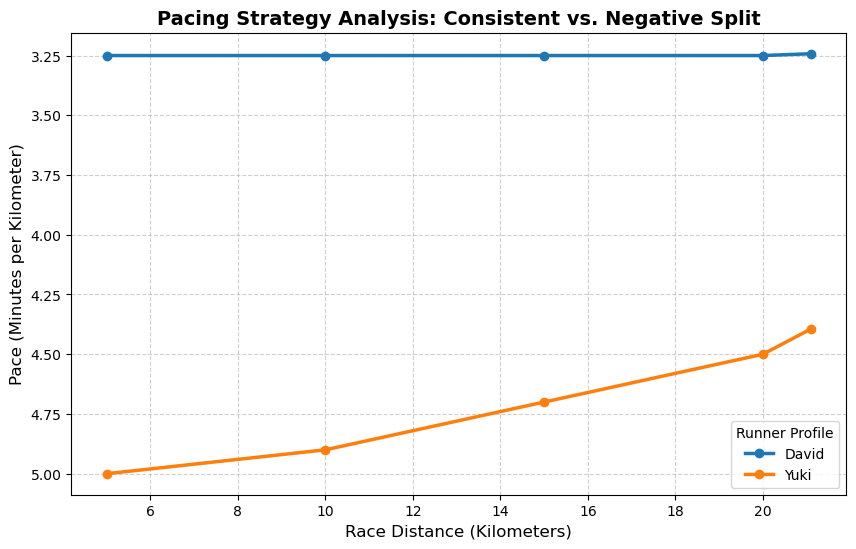


--- KPI: Pace Variance (Consistency Metric) ---


,FirstName,Pace_Std_Dev (Variance)
0,David,0.003388
1,Yuki,0.256742


In [2]:
import mysql.connector
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# Phase 8.1 & 8.2: Data Extraction & Cleaning
# ---------------------------------------------------------

try:
    connection = mysql.connector.connect(
        host="localhost",
        user="root",
        password="ansh1535", # IMPORTANT: Replace before running
        database="race_pacing_engine"
    )
    
    # We are pulling the raw split data for David (Consistent) and Yuki (Negative Split) to analyze pacing
    query = """
    SELECT 
        sl.RegID,
        r.FirstName,
        r.Gender,
        vw.AgeOnRaceDay,
        sl.Kilometer_Mark,
        sl.Chip_Timestamp
    FROM SplitLogs sl
    JOIN Registrations reg ON sl.RegID = reg.RegID
    JOIN Runners r ON reg.RunnerID = r.RunnerID
    JOIN vw_runner_demographics vw ON reg.RegID = vw.RegID
    WHERE reg.RaceID = 1 AND sl.RegID IN (5, 8)
    ORDER BY sl.RegID, sl.Kilometer_Mark;
    """

    df_splits = pd.read_sql(query, connection)
    print("✅ Data Extracted Successfully.\n")

except mysql.connector.Error as e:
    print(f"❌ Error: {e}")
finally:
    if 'connection' in locals() and connection.is_connected():
        connection.close()

# 1. Check for Missing Values (Cleaning)
print("Missing Values Check:")
print(df_splits.isnull().sum())

# 2. Fix Data Types (Cleaning/Validation)
# Ensure timestamps are actual pandas datetime objects so we can perform math on them
df_splits['Chip_Timestamp'] = pd.to_datetime(df_splits['Chip_Timestamp'])
print("\nData Types Validated:\n", df_splits.dtypes)


# ---------------------------------------------------------
# Phase 8.4: Feature Engineering (The Analytical Heavy Lifting)
# ---------------------------------------------------------
# We need to calculate how long each 5km segment took, and the pace per km.

# 1. Calculate 'Previous Mat Timestamp' using shift() (Pandas equivalent of SQL LAG())
df_splits['Previous_Timestamp'] = df_splits.groupby('RegID')['Chip_Timestamp'].shift(1)

# 2. Calculate the Duration of the Split in Minutes
df_splits['Split_Duration_Mins'] = (df_splits['Chip_Timestamp'] - df_splits['Previous_Timestamp']).dt.total_seconds() / 60

# 3. Calculate 'Previous Kilometer Mark' to find the exact distance of this split
df_splits['Previous_KM'] = df_splits.groupby('RegID')['Kilometer_Mark'].shift(1)

# Handle the first split (5km). The previous KM was 0, and the start time was 06:00:00
race_start_time = pd.to_datetime('2026-09-10 06:00:00')

df_splits['Previous_Timestamp'] = df_splits['Previous_Timestamp'].fillna(race_start_time)
df_splits['Previous_KM'] = df_splits['Previous_KM'].fillna(0.0)

# Recalculate duration for the first split now that NaNs are filled
df_splits['Split_Duration_Mins'] = (df_splits['Chip_Timestamp'] - df_splits['Previous_Timestamp']).dt.total_seconds() / 60

# 4. Calculate Distance Covered in this specific split
df_splits['Split_Distance_KM'] = df_splits['Kilometer_Mark'] - df_splits['Previous_KM']

# 5. Calculate Pace (Minutes per Kilometer)
df_splits['Pace_Min_Per_KM'] = df_splits['Split_Duration_Mins'] / df_splits['Split_Distance_KM']

# Clean up temporary columns we don't need for the final report
df_splits = df_splits.drop(columns=['Previous_Timestamp', 'Previous_KM'])

print("\n🚀 Feature Engineering Complete. Final DataFrame:")
display(df_splits)

# ---------------------------------------------------------
# Phase 8.6 & 8.7: KPI Calculation & Visualization
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import os


# 1. Create Output directory if it doesn't exist to avoid save errors
os.makedirs('../Output/Charts', exist_ok=True)

# 2. Set up the visualization canvas
plt.figure(figsize=(10, 6))

# 3. Loop through each runner and plot their pacing line
for runner_name in df_splits['FirstName'].unique():
    runner_data = df_splits[df_splits['FirstName'] == runner_name]
    plt.plot(runner_data['Kilometer_Mark'], runner_data['Pace_Min_Per_KM'], 
             marker='o', linewidth=2.5, label=f'{runner_name}')

# 4. Format the chart professionally
plt.title('Pacing Strategy Analysis: Consistent vs. Negative Split', fontsize=14, fontweight='bold')
plt.xlabel('Race Distance (Kilometers)', fontsize=12)
plt.ylabel('Pace (Minutes per Kilometer)', fontsize=12)

# IMPORTANT: In running, a LOWER pace number means a FASTER speed.
# We invert the Y-axis so the visual line going "up" means the runner is speeding up.
plt.gca().invert_yaxis() 

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Runner Profile')

# 5. Save the chart to your Output folder
chart_path = '../Output/Charts/pacing_strategy_analysis.png'
plt.savefig(chart_path, bbox_inches='tight')
print(f"\n✅ Chart successfully saved to: {chart_path}")

plt.show()

# ---------------------------------------------------------
# Phase 8.6: KPI Calculation (Pace Variance)
# ---------------------------------------------------------
print("\n--- KPI: Pace Variance (Consistency Metric) ---")
# The Standard Deviation of pace tells us how consistent a runner is. 
# Lower std_dev = High consistency. Higher std_dev = Erratic pacing.
kpi_variance = df_splits.groupby('FirstName')['Pace_Min_Per_KM'].std().reset_index()
kpi_variance.rename(columns={'Pace_Min_Per_KM': 'Pace_Std_Dev (Variance)'}, inplace=True)
display(kpi_variance)